[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/abhiksark/pycon-italy-2026-workshop/blob/main/notebooks/04-softmax-blur-triton.ipynb)

# 04 · Softmax & blur in Triton - _fusion, halos, visible payoff_

Two ideas, both fused into single kernels.

- **Part 1**: a fused softmax - the Part 3 memory wall, beaten in one kernel.
- **Part 2**: a 1D image blur worked example - same fusion idea applied to a 2D stencil.
- **Part 3 (bonus)**: a 2D blur with halos - the full tile-and-halo pattern that prefigures nb05.

If the speaker calls a kill-switch on the bonus, the bonus cells (and the OpenCV/Proton benchmarks that use them) are still here for you to try after the workshop.

The visible payoff: side-by-side `matplotlib` of original vs blurred. You can _see_ whether your kernel works.

## Environment bootstrap

In [1]:
import importlib, subprocess, sys
def ensure(pip_name, import_name=None):
    try: importlib.import_module(import_name or pip_name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_name])
ensure('triton')
ensure('Pillow', 'PIL')
ensure('matplotlib')
ensure('opencv-python', 'cv2')
import torch, triton, numpy as np
import triton.language as tl
from PIL import Image
import matplotlib.pyplot as plt
assert torch.cuda.is_available(), 'No GPU detected.'

In [ ]:
# Colab path bootstrap: if we are not at the repo root, clone the repo and chdir.
import os, subprocess, pathlib
if not pathlib.Path('notebooks/shared').is_dir():
    repo_url = os.environ.get('WORKSHOP_REPO_URL', 'https://github.com/abhiksark/pycon-italy-2026-workshop.git')
    target = './content/pycon-italy'
    if not pathlib.Path(target).exists():
        subprocess.check_call(['git', 'clone', '--depth=1', repo_url, target])
    os.chdir(target)
print(f'cwd: {os.getcwd()}')

# Part 1 · Fused softmax: collapse the memory wall

Part 3 set up the memory wall. **Naive softmax** in three passes:

```python
m = x.max(dim=1, keepdim=True).values
e = (x - m).exp()
out = e / e.sum(dim=1, keepdim=True)
```

Three kernel launches. ~6N bytes of HBM traffic for ~3N FLOPs → **AI ≈ ½**. Sits well below the ridge.

**Fused softmax** does the whole thing in one kernel — one read of `x`, one write of `out`, ~2N bytes. We launch one program per row; the whole row lives in registers while we do max → `exp(x − m)` → sum → divide.

Three TODOs.

In [ ]:
n_rows, n_cols = 1823, 1200
x = torch.randn(n_rows, n_cols, device='cuda', dtype=torch.float32)
y = torch.empty_like(x)
reference = torch.softmax(x, dim=1)
print(f'input: ({n_rows}, {n_cols})')

In [ ]:
@triton.jit
def fused_softmax_kernel(
    x_ptr, y_ptr,
    n_cols,
    BLOCK_SIZE: tl.constexpr,
):
    # One program per row.
    row = tl.program_id(axis=0)
    cols = tl.arange(0, BLOCK_SIZE)
    mask = cols < n_cols
    row_offset = row * n_cols

    # TODO (1/3): load this row into a BLOCK_SIZE-long vector.
    # Mask off out-of-range cols with `other=-float('inf')` so they do
    # not drag the row max down.
    # x = tl.load(x_ptr + row_offset + cols, mask=mask, other=-float('inf'))

    # TODO (2/3): the fused math - subtract the row max, exponentiate,
    # divide by the sum. Four lines, all in registers - nothing touches HBM.
    # m = tl.max(x, axis=0)
    # e = tl.exp(x - m)
    # s = tl.sum(e, axis=0)
    # out = e / s

    # TODO (3/3): store the result back, masked.
    # tl.store(y_ptr + row_offset + cols, out, mask=mask)

    pass

In [ ]:
BLOCK_SIZE = triton.next_power_of_2(n_cols)  # 2048 for n_cols=1200
grid = (n_rows,)
fused_softmax_kernel[grid](x, y, n_cols, BLOCK_SIZE=BLOCK_SIZE)
torch.testing.assert_close(y, reference, rtol=1e-5, atol=1e-5)
print('correctness: ok')

## Naive vs fused - the payoff Part 3 promised

Time the fused Triton kernel against the naive three-pass PyTorch decomposition. Effective bandwidth = bytes moved ÷ wall time.

In [ ]:
import sys, pathlib
for _root in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
    if (_root / 'notebooks' / 'shared' / 'benchmark_utils.py').is_file():
        if str(_root) not in sys.path:
            sys.path.insert(0, str(_root))
        break
from notebooks.shared.benchmark_utils import median_seconds

def naive_softmax(x):
    # Three separate ops = three kernel launches, ~6N bytes of HBM traffic.
    m = x.max(dim=1, keepdim=True).values
    e = (x - m).exp()
    return e / e.sum(dim=1, keepdim=True)

def run_triton():
    fused_softmax_kernel[grid](x, y, n_cols, BLOCK_SIZE=BLOCK_SIZE)
    torch.cuda.synchronize()

def run_naive():
    naive_softmax(x)
    torch.cuda.synchronize()

t_triton = median_seconds(run_triton, runs=50, warmup=5) * 1e3
t_naive  = median_seconds(run_naive,  runs=50, warmup=5) * 1e3

# Naive moves ~6N traffic across its three passes; fused moves 2N.
n_bytes_fused = 2 * x.numel() * x.element_size()
n_bytes_naive = 6 * x.numel() * x.element_size()
gbs_triton = n_bytes_fused / (t_triton * 1e-3) / 1e9
gbs_naive  = n_bytes_naive / (t_naive  * 1e-3) / 1e9

T4_PEAK_HBM_GBS = 320.0
print(f'naive PyTorch (3 passes): {t_naive:7.3f} ms | {gbs_naive:6.1f} GB/s effective ({gbs_naive/T4_PEAK_HBM_GBS*100:.0f}% T4 peak)')
print(f'fused Triton  (1 pass) :  {t_triton:7.3f} ms | {gbs_triton:6.1f} GB/s effective ({gbs_triton/T4_PEAK_HBM_GBS*100:.0f}% T4 peak)')
print(f'speedup: {t_naive / t_triton:.2f}x by collapsing three passes into one kernel.')

Three kernel launches collapsed to one. The memory wall is *partially* climbed - fusion got us closer to the ridge, but to climb the rest we need tiling (nb05).

Next: the same one-kernel-per-tile idea applied to 2D - image blur. Worked example first, then a bonus that prefigures the tile-and-halo pattern you'll see in nb05.

# Part 2 · Image blur (worked example)

*Bologna's Two Towers (Asinelli + Garisenda) - photo by Volodymyr Vlasenko, [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/), [via Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Asinelli_Tower_and_Garisenda_Tower_Bologna_Italy.jpg). 2944x4444 ≈ 13 MP.*

In [5]:
src = Image.open('notebooks/shared/assets/blur-source-bologna.jpg').convert('RGB')
src_np = np.asarray(src, dtype=np.float32) / 255.0  # (H, W, 3); H=4444, W=2944
H, W, _ = src_np.shape
# Operate on the luminance channel for simplicity. We will blur a single channel.
lum = src_np.mean(axis=2)  # (H, W) float32 in [0, 1]
lum_t = torch.from_numpy(lum).cuda().contiguous()
out_t = torch.empty_like(lum_t)
print(f'image {H}x{W}')

image 4444x2944


## 1D horizontal blur (one program per row)

Each program handles one row. For every pixel `(row, col)` we average the three pixels at columns `col-1`, `col`, `col+1`. The lookups at `col-1` and `col+1` need masked **halos** when they step off the row.

This is a worked example - read the kernel, run the launch, look at the matplotlib payoff below.

In [6]:
@triton.jit
def blur_1d(in_ptr, out_ptr, H, W, BLOCK_W: tl.constexpr):
    row = tl.program_id(axis=0)
    cols = tl.arange(0, BLOCK_W)

    # Column mask - protects the tail when W is not a power of two.
    mask = cols < W
    base = row * W

    # Load three neighbours with halo masking - left/right may step off the row.
    left   = tl.load(in_ptr + base + (cols - 1), mask=(cols - 1 >= 0) & mask, other=0.0)
    centre = tl.load(in_ptr + base + cols,       mask=mask,                   other=0.0)
    right  = tl.load(in_ptr + base + (cols + 1), mask=(cols + 1 < W) & mask,  other=0.0)

    # Average and write back.
    tl.store(out_ptr + base + cols, (left + centre + right) / 3.0, mask=mask)

In [8]:
BLOCK_W = triton.next_power_of_2(W)
grid = (H,)
blur_1d[grid](lum_t, out_t, H, W, BLOCK_W=BLOCK_W)

# Compare with a numpy reference
import numpy as np
ref = np.zeros_like(lum)
ref[:, 1:-1] = (lum[:, :-2] + lum[:, 1:-1] + lum[:, 2:]) / 3.0
ref[:, 0] = (lum[:, 0] + lum[:, 1]) / 3.0
ref[:, -1] = (lum[:, -2] + lum[:, -1]) / 3.0
torch.testing.assert_close(out_t, torch.from_numpy(ref).cuda(), rtol=1e-3, atol=1e-3)
print('core ok')

core ok


## Look at the result

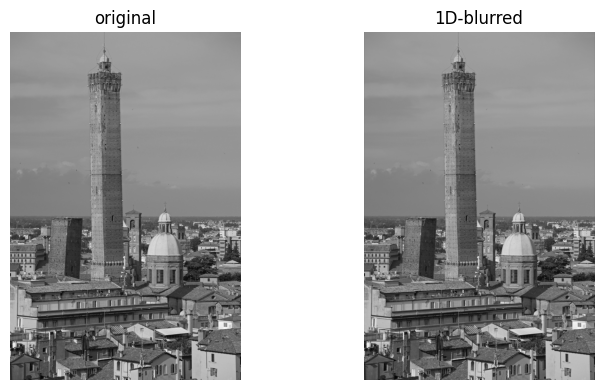

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(lum, cmap='gray'); axes[0].set_title('original')
axes[1].imshow(out_t.cpu().numpy(), cmap='gray'); axes[1].set_title('1D-blurred')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

# Part 3 · Bonus challenge: 2D blur with halos

Same idea but in 2D: every pixel averages its 3x3 neighbourhood. We tile the output into `(BLOCK_M, BLOCK_N)` blocks; each program handles one tile and loads a tile-plus-halo from the input.

Two TODOs.

Mental picture: each output tile reads a 1-pixel halo. Halo cells outside the image are masked to 0.

![diagram](https://raw.githubusercontent.com/abhiksark/pycon-italy-2026-workshop/main/notebooks/shared/diagrams/nb04-blur-halo.png)

![diagram](https://raw.githubusercontent.com/abhiksark/pycon-italy-2026-workshop/main/notebooks/shared/diagrams/pointer-grid-2d.png)

In [10]:
@triton.jit
def blur_2d(in_ptr, out_ptr, H, W,
            BLOCK_M: tl.constexpr, BLOCK_N: tl.constexpr):
    pid_m = tl.program_id(axis=0)
    pid_n = tl.program_id(axis=1)
    row_offsets = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)
    col_offsets = pid_n * BLOCK_N + tl.arange(0, BLOCK_N)
    row_mask = row_offsets < H
    col_mask = col_offsets < W

    total = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)
    for dy in tl.static_range(-1, 2):
        for dx in tl.static_range(-1, 2):
            r = row_offsets[:, None] + dy
            c = col_offsets[None, :] + dx
            m = (r >= 0) & (r < H) & (c >= 0) & (c < W)
            v = tl.load(in_ptr + r * W + c, mask=m, other=0.0)
            total += v

    out_ptrs = out_ptr + row_offsets[:, None] * W + col_offsets[None, :]
    tl.store(out_ptrs, total / 9.0, mask=row_mask[:, None] & col_mask[None, :])


bonus ok


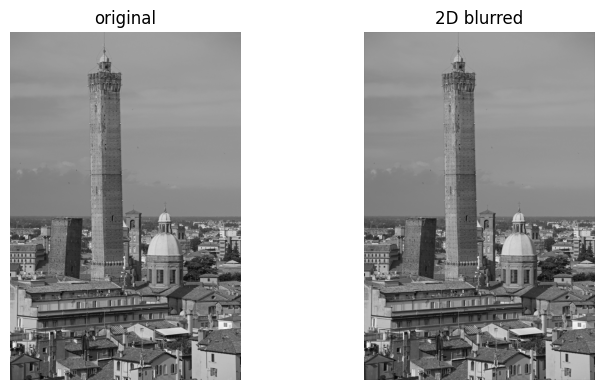

In [11]:
out_t2 = torch.empty_like(lum_t)
BLOCK_M, BLOCK_N = 32, 32
assert lum_t.is_contiguous(), 'blur_2d requires a contiguous tensor'
grid = (triton.cdiv(H, BLOCK_M), triton.cdiv(W, BLOCK_N))
blur_2d[grid](lum_t, out_t2, H, W, BLOCK_M=BLOCK_M, BLOCK_N=BLOCK_N)

# Reference via padding + slicing
pad = np.pad(lum, 1, mode='constant')
ref2 = sum(
    pad[1+dy:1+dy+H, 1+dx:1+dx+W] for dy in (-1, 0, 1) for dx in (-1, 0, 1)
) / 9.0
torch.testing.assert_close(out_t2, torch.from_numpy(ref2.astype(np.float32)).cuda(), rtol=1e-3, atol=1e-3)
print('bonus ok')

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(lum, cmap='gray'); axes[0].set_title('original')
axes[1].imshow(out_t2.cpu().numpy(), cmap='gray'); axes[1].set_title('2D blurred')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

## How fast is this? Triton vs. OpenCV

OpenCV's `cv2.blur` is the right baseline — a heavily SIMD-optimised, multi-threaded 3x3 box filter is what a CPU does at production speed. We time both with their natural tools (CUDA events for GPU, `time.perf_counter` for CPU), then print the speedup.

In [12]:
# How fast is this? Triton vs. OpenCV
import statistics, time, sys, pathlib
import cv2
# Make `from notebooks.shared.*` resolve whether Jupyter was launched
# from the repo root, from notebooks/, or anywhere below.
for _root in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
    if (_root / 'notebooks' / 'shared' / 'benchmark_utils.py').is_file():
        if str(_root) not in sys.path:
            sys.path.insert(0, str(_root))
        break
from notebooks.shared.benchmark_utils import median_seconds

def run_triton_blur():
    blur_2d[grid](lum_t, out_t2, H, W, BLOCK_M=BLOCK_M, BLOCK_N=BLOCK_N)
    torch.cuda.synchronize()

triton_ms = median_seconds(run_triton_blur, runs=20, warmup=5) * 1000

# Effective HBM traffic: read the image once, write it once.
n_bytes = lum.nbytes * 2
gbs = n_bytes / (triton_ms / 1000) / 1e9

def run_cv2_blur():
    cv2.blur(lum, (3, 3))

for _ in range(3): run_cv2_blur()                          # warm up the CPU caches
cv2_runs = []
for _ in range(20):
    t0 = time.perf_counter()
    run_cv2_blur()
    cv2_runs.append(time.perf_counter() - t0)
cv2_ms = statistics.median(cv2_runs) * 1000

print(f'Triton blur_2d (T4):    {triton_ms:6.2f} ms   |   {gbs:5.0f} GB/s')
print(f'OpenCV cv2.blur (CPU):  {cv2_ms:6.2f} ms')
print(f'Speedup:                {cv2_ms / triton_ms:5.1f}x')

Triton blur_2d (T4):      0.44 ms   |     238 GB/s
OpenCV cv2.blur (CPU):   12.18 ms
Speedup:                 27.7x


## Profile with Proton

Same kernel, this time through `triton.profiler` — emits a `.hatchet` trace you can open with `proton-viewer` for per-kernel attribution. The slide we just showed, in action.

In [13]:
# Same kernel, profiled with triton.profiler. Writes blur.hatchet.
try:
    import triton.profiler as proton
    proton.start('blur')
    blur_2d[grid](lum_t, out_t2, H, W, BLOCK_M=BLOCK_M, BLOCK_N=BLOCK_N)
    torch.cuda.synchronize()
    proton.finalize()
    print('Wrote blur.hatchet')
    print('Inspect:   proton-viewer -m time/ms,gbyte/s blur.hatchet')
except (ImportError, AttributeError) as exc:
    print(f'Proton not available in this Triton build: {exc}')

Wrote blur.hatchet
Inspect:   proton-viewer -m time/ms,gbyte/s blur.hatchet


## Teaching beat

Every load that goes outside the image boundary must be masked. This is the same pattern as the vector-add tail, generalised to 2D - just with **two** boundary checks instead of one.